In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
DATASET_PATH = r"D:\ML-PROJECTS\Emotion analysis\dataset\voice-Mozilla"

CSV_FILE = os.path.join(DATASET_PATH, "cv-valid-train.csv")

print(CSV_FILE)

D:\ML-PROJECTS\Emotion analysis\dataset\voice-Mozilla\cv-valid-train.csv


In [3]:
df = pd.read_csv(CSV_FILE)

print("Dataset Shape :", df.shape)

df.head()

Dataset Shape : (195776, 8)


,filename,text,up_votes,down_votes,age,gender,accent,duration
0,cv-valid-train/sample-000000.mp3,learn to recognize omens and follow them the o...,1,0,NaN,NaN,NaN,NaN
1,cv-valid-train/sample-000001.mp3,everything in the universe evolved he said,1,0,NaN,NaN,NaN,NaN
2,cv-valid-train/sample-000002.mp3,you came so that you could learn about your dr...,1,0,NaN,NaN,NaN,NaN
3,cv-valid-train/sample-000003.mp3,so now i fear nothing because it was those ome...,1,0,NaN,NaN,NaN,NaN
4,cv-valid-train/sample-000004.mp3,if you start your emails with greetings let me...,3,2,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 195776 entries, 0 to 195775
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   filename    195776 non-null  str    
 1   text        195776 non-null  str    
 2   up_votes    195776 non-null  int64  
 3   down_votes  195776 non-null  int64  
 4   age         73768 non-null   str    
 5   gender      74059 non-null   str    
 6   accent      64711 non-null   str    
 7   duration    0 non-null       float64
dtypes: float64(1), int64(2), str(5)
memory usage: 28.2 MB


In [5]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
duration,195776,100.00
accent,131065,66.95
age,122008,62.32
gender,121717,62.17
down_votes,0,0.00
up_votes,0,0.00
text,0,0.00
filename,0,0.00


gender
NaN       121717
male       55029
female     18249
other        781
Name: count, dtype: int64


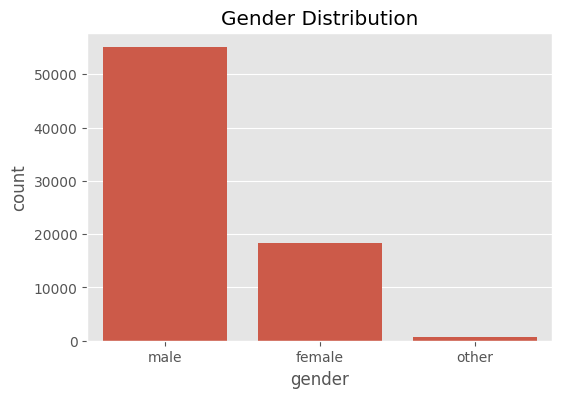

In [6]:
print(df["gender"].value_counts(dropna=False))

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="gender",
    order=df["gender"].value_counts().index
)

plt.title("Gender Distribution")
plt.show()

age
NaN          122008
twenties      23003
thirties      18303
fourties      11100
fifties        9466
teens          5441
sixties        4584
seventies      1632
eighties        239
Name: count, dtype: int64


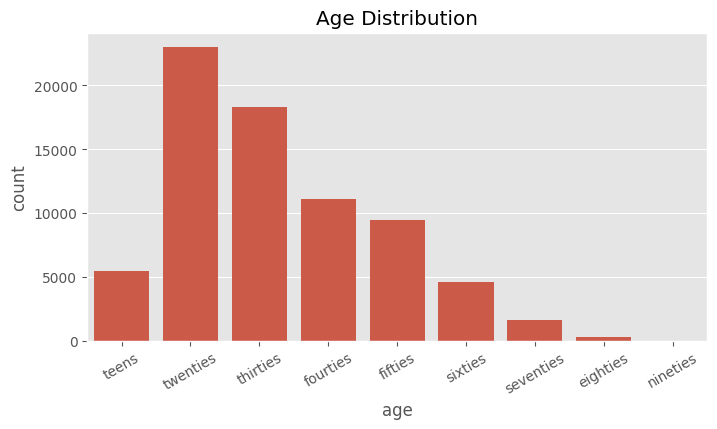

In [7]:
print(df["age"].value_counts(dropna=False))

plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x="age",
    order=[
        "teens",
        "twenties",
        "thirties",
        "fourties",
        "fifties",
        "sixties",
        "seventies",
        "eighties",
        "nineties"
    ]
)

plt.xticks(rotation=30)

plt.title("Age Distribution")

plt.show()

In [10]:
sample = df.iloc[0]["filename"]

parts = sample.split("/")

audio_path = os.path.join(
    DATASET_PATH,
    parts[0],      # cv-other-train
    parts[0],      # cv-other-train (second folder)
    parts[1]       # sample-000000.mp3
)

print(audio_path)
print(os.path.exists(audio_path))

D:\ML-PROJECTS\Emotion analysis\dataset\voice-Mozilla\cv-valid-train\cv-valid-train\sample-000000.mp3
True


In [11]:
gender_df = df[
    df["gender"].isin(["male", "female"])
].copy()

gender_df.reset_index(drop=True, inplace=True)

print(gender_df.shape)

gender_df.head()

(73278, 8)


,filename,text,up_votes,down_votes,age,gender,accent,duration
0,cv-valid-train/sample-000005.mp3,a shepherd may like to travel but he should ne...,1,0,twenties,female,us,NaN
1,cv-valid-train/sample-000008.mp3,put jackie right on the staff,3,0,seventies,male,us,NaN
2,cv-valid-train/sample-000013.mp3,but he had found a guide and didn't want to mi...,1,0,thirties,female,us,NaN
3,cv-valid-train/sample-000014.mp3,as they began to decorate the hallway a silhou...,1,0,sixties,male,england,NaN
4,cv-valid-train/sample-000019.mp3,then they got ahold of some dough and went goofy,1,0,fifties,male,australia,NaN


In [12]:
age_df = df[
    (df["gender"]=="male") &
    (df["age"].notna())
].copy()

age_df.reset_index(drop=True, inplace=True)

print(age_df.shape)

age_df.head()

(54593, 8)


,filename,text,up_votes,down_votes,age,gender,accent,duration
0,cv-valid-train/sample-000008.mp3,put jackie right on the staff,3,0,seventies,male,us,NaN
1,cv-valid-train/sample-000014.mp3,as they began to decorate the hallway a silhou...,1,0,sixties,male,england,NaN
2,cv-valid-train/sample-000019.mp3,then they got ahold of some dough and went goofy,1,0,fifties,male,australia,NaN
3,cv-valid-train/sample-000020.mp3,it was faintly marked with transverse stripes ...,5,1,thirties,male,england,NaN
4,cv-valid-train/sample-000023.mp3,i had seen all that it would presently bring me,5,0,thirties,male,us,NaN


In [17]:
SAVE_DIR = os.path.join(DATASET_PATH, "processed")

os.makedirs(SAVE_DIR, exist_ok=True)

gender_df.to_csv(
    os.path.join(SAVE_DIR, "gender_metadata.csv"),
    index=False
)

age_df.to_csv(
    os.path.join(SAVE_DIR, "age_metadata.csv"),
    index=False
)

print("Metadata Saved Successfully")

Metadata Saved Successfully
